# 01 — Data quality: leukipp 2021 Reddit submissions, four subreddits

Before touching any factor code, I wanted to know what the corpus actually looks like. Full 2021 coverage with no gaps? How many documents survive entity-linking and FinBERT scoring? Which tickers dominate, and is the tail thin enough to be a problem for per-stock daily aggregation? Are bot accounts meaningfully inflating mention counts?

The four subreddits — `wallstreetbets`, `stocks`, `investing`, `options` — give a useful within-2021 contrast: meme-heavy WSB vs more measured r/stocks vs longer-horizon r/investing vs leverage-skewed r/options.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCORED_DIR = REPO_ROOT / "data" / "processed" / "scored_leukipp"
RAW_DIR    = REPO_ROOT / "data" / "raw" / "kaggle" / "finance_multi"

print("scored dir:", SCORED_DIR)
print("raw dir   :", RAW_DIR)

scored dir: C:\Users\Pan\Desktop\code\side project\alt-data-sentiment\data\processed\scored_leukipp
raw dir   : C:\Users\Pan\Desktop\code\side project\alt-data-sentiment\data\raw\kaggle\finance_multi


## Raw archive coverage by subreddit

The submissions-per-day chart tells me whether any subreddit has gaps in 2021 — leukipp is advertised as a complete year, so any missing stretches would be a problem worth knowing about before building factors on top of it.

In [2]:
SUBREDDITS = ("wallstreetbets", "stocks", "investing", "options")
USECOLS = ["id", "created"]

raw_counts = []
for sub in SUBREDDITS:
    csv = RAW_DIR / sub / "submissions_reddit.csv"
    df = pd.read_csv(csv, usecols=USECOLS)
    dt = pd.to_datetime(df["created"], errors="coerce")
    daily = dt.dt.normalize().value_counts().sort_index()
    daily.name = sub
    raw_counts.append(daily)
raw_panel = pd.concat(raw_counts, axis=1).fillna(0).astype(int)
print(f"raw panel:  {raw_panel.shape[0]} days  ×  {raw_panel.shape[1]} subreddits")
print(f"date range: {raw_panel.index.min().date()}  ->  {raw_panel.index.max().date()}")
print("\\nrow totals (submissions per subreddit):")
print(raw_panel.sum().to_string())

raw panel:  365 days  ×  4 subreddits
date range: 2021-01-01  ->  2021-12-31
\nrow totals (submissions per subreddit):
wallstreetbets    775326
stocks             75857
investing          41912
options            28782


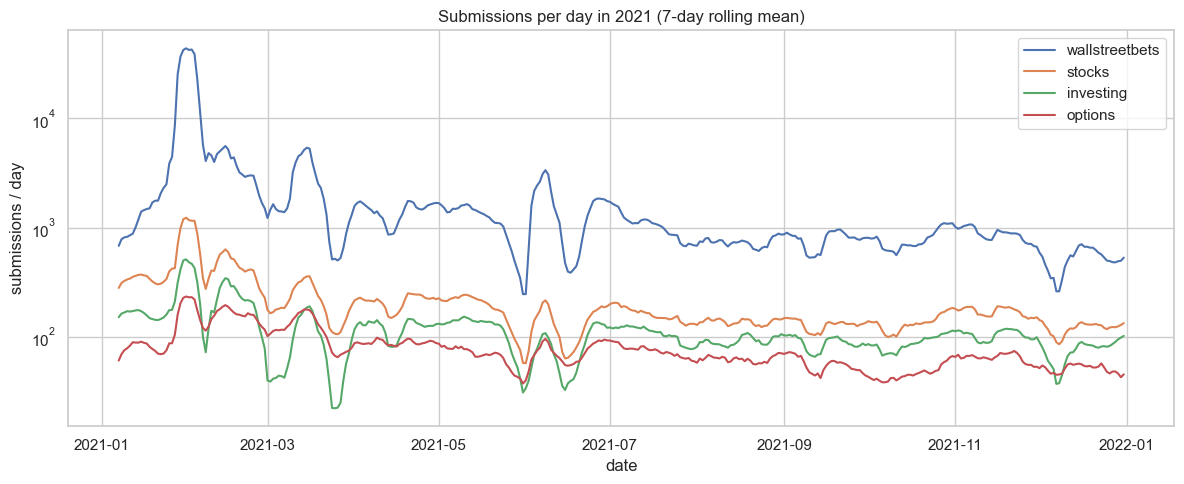

Note the GameStop spike around 2021-01-27 in r/wallstreetbets.


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
for sub in SUBREDDITS:
    ax.plot(raw_panel.index, raw_panel[sub].rolling(7).mean(), label=sub, lw=1.5)
ax.set_title("Submissions per day in 2021 (7-day rolling mean)")
ax.set_xlabel("date"); ax.set_ylabel("submissions / day")
ax.legend(loc="upper right")
ax.set_yscale("log")
plt.tight_layout(); plt.show()
print("Note the GameStop spike around 2021-01-27 in r/wallstreetbets.")

## After entity-linking + FinBERT: what survives?

I score every document once and fan out the (pos, neg, neu) triple to every S&P 500 ticker linked to that document, so row count is `(linked_documents) × (avg tickers per linked doc)`. Documents with zero linked tickers are dropped — they contribute nothing to the cross-section.

In [4]:
parts = sorted(SCORED_DIR.glob("part_*.parquet"))
print(f"{len(parts)} parquet parts")
sc = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
print(f"scored rows (doc x ticker)  : {len(sc):,}")
print(f"unique linked documents     : {sc['doc_id'].nunique():,}")
print(f"unique tickers              : {sc['ticker'].nunique()}")
print(f"avg tickers per linked doc  : {len(sc)/sc['doc_id'].nunique():.2f}")
print()

linked_per_sub = sc.groupby("subreddit")["doc_id"].nunique()
total_per_sub = raw_panel.sum().rename(linked_per_sub.index.name)
link_rate = (linked_per_sub / total_per_sub).rename("link_rate")
out = pd.concat([
    total_per_sub.rename("raw_subs"),
    linked_per_sub.rename("linked_docs"),
    (linked_per_sub / total_per_sub).rename("link_rate"),
], axis=1)
out.loc["TOTAL"] = [out["raw_subs"].sum(), out["linked_docs"].sum(),
                    out["linked_docs"].sum() / out["raw_subs"].sum()]
print(out.to_string(float_format=lambda x: f"{x:,.1f}" if x > 1 else f"{x:.3f}"))

11 parquet parts


scored rows (doc x ticker)  : 76,124
unique linked documents     : 55,412
unique tickers              : 470
avg tickers per linked doc  : 1.37

                raw_subs  linked_docs  link_rate
wallstreetbets 775,326.0     41,559.0      0.054
stocks          75,857.0      7,557.0      0.100
investing       41,912.0      2,034.0      0.049
options         28,782.0      4,262.0      0.148
TOTAL          921,877.0     55,412.0      0.060


## Top-mentioned tickers — and how concentrated they are

Retail discussion almost always clusters around a handful of names. If the top-20 absorbs more than half the mention mass, the per-stock daily aggregation will be very sparse for most of the S&P 500 universe.

In [5]:
top_tickers = sc["ticker"].value_counts().head(20)
print("Top 20 most-discussed tickers (across all 4 subreddits):")
print(top_tickers.to_string())
share_top20 = top_tickers.sum() / len(sc)
share_top50 = sc["ticker"].value_counts().head(50).sum() / len(sc)
print(f"\\nshare of all (doc x ticker) rows held by top 20 = {share_top20:.1%}")
print(f"share held by top 50                            = {share_top50:.1%}")

Top 20 most-discussed tickers (across all 4 subreddits):
ticker
ON      6584
TSLA    5469
PLTR    5452
ALL     4763
ARE     4007
NOW     3229
AMD     2672
AAPL    2541
AMZN    1463
COIN    1412
NVDA    1352
SO      1316
MSFT    1304
HAS     1082
HOOD    1018
PSA      933
PM       881
GM       853
DTE      821
GE       737
\nshare of all (doc x ticker) rows held by top 20 = 62.9%
share held by top 50                            = 77.8%


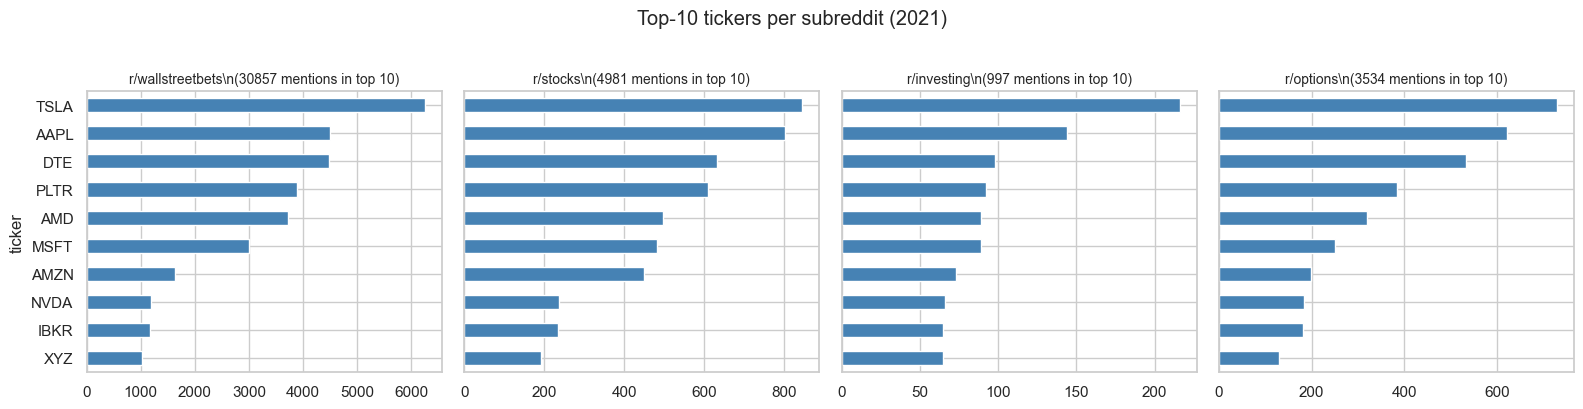

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, sub in zip(axes, SUBREDDITS):
    s = sc[sc["subreddit"] == sub]["ticker"].value_counts().head(10)
    s.plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"r/{sub}\\n({s.sum()} mentions in top 10)", fontsize=10)
    ax.invert_yaxis()
plt.suptitle("Top-10 tickers per subreddit (2021)", y=1.02)
plt.tight_layout(); plt.show()

## Bot heuristic: high-frequency authors

I flagged any author posting more than 20 documents on a single subreddit in a single day as a likely bot. I don't filter them out for the factor — the volume is mostly genuine — but I wanted to record what the heuristic would remove. If the answer were "20% of rows," it'd be worth a harder look.

In [7]:
# Need the raw archive again for the author column
author_counts = []
for sub in SUBREDDITS:
    csv = RAW_DIR / sub / "submissions_reddit.csv"
    df = pd.read_csv(csv, usecols=["id", "created", "author"])
    df["dt"] = pd.to_datetime(df["created"], errors="coerce").dt.normalize()
    g = df.groupby(["author", "dt"]).size()
    bot_flagged = g[g > 20]
    author_counts.append((sub, df["author"].nunique(), int(bot_flagged.shape[0])))
print("Per-subreddit bot heuristic (threshold = >20 posts/author/day):")
for sub, n_auth, n_bot in author_counts:
    print(f"  r/{sub:16s}  unique authors = {n_auth:>6,}  bot-flagged author-days = {n_bot:,}")

Per-subreddit bot heuristic (threshold = >20 posts/author/day):
  r/wallstreetbets    unique authors = 373,850  bot-flagged author-days = 375
  r/stocks            unique authors = 43,832  bot-flagged author-days = 125
  r/investing         unique authors = 24,989  bot-flagged author-days = 97
  r/options           unique authors = 15,298  bot-flagged author-days = 8


## Sentiment distribution — does FinBERT skew?

FinBERT was trained on financial news. Reddit submissions are often terse one-liners or link posts — nothing like a Reuters article — so I expected the model to default heavily toward neutral when it couldn't read enough context. The distribution below confirms it: `score_neu` dominates, which means the usable signal lives in a narrow (pos − neg) band.

Mean FinBERT class probabilities:
score_pos   0.115
score_neg   0.166
score_neu   0.719


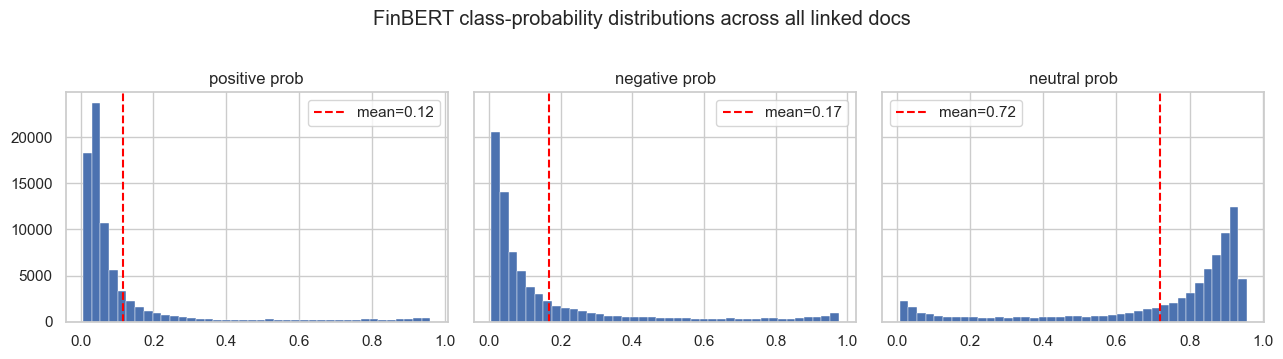

In [8]:
print("Mean FinBERT class probabilities:")
print(sc[["score_pos", "score_neg", "score_neu"]].mean().to_string(float_format=lambda x: f"{x:.3f}"))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, col, title in zip(
    axes,
    ["score_pos", "score_neg", "score_neu"],
    ["positive prob", "negative prob", "neutral prob"],
):
    ax.hist(sc[col], bins=40, edgecolor="white", linewidth=0.3)
    ax.set_title(title)
    ax.axvline(sc[col].mean(), color="red", linestyle="--",
               label=f"mean={sc[col].mean():.2f}")
    ax.legend()
plt.suptitle("FinBERT class-probability distributions across all linked docs", y=1.02)
plt.tight_layout(); plt.show()

## Spot check: 10 random ticker extractions

Ten random rows isn't a real precision/recall study. What I'm looking for is obvious blowups — a common English word getting through the ticker filter as a symbol, or a completely off-topic post being linked to a financial name. One or two borderline cases is fine; systematic noise would not be.

In [9]:
# Pull text back from the raw archive, then show 10 random rows
sub_to_csv = {sub: RAW_DIR / sub / "submissions_reddit.csv" for sub in SUBREDDITS}
samples = sc.sample(10, random_state=7).reset_index(drop=True)
sample_text = []
for _, row in samples.iterrows():
    raw_id = row["doc_id"].split("/")[-1]
    sub = row["subreddit"]
    df = pd.read_csv(sub_to_csv[sub], usecols=["id", "title", "selftext"])
    hit = df[df["id"] == raw_id]
    if hit.empty:
        sample_text.append(("", ""))
    else:
        sample_text.append((str(hit.iloc[0]["title"])[:80],
                            str(hit.iloc[0].get("selftext", ""))[:120]))
samples["title"] = [t for t, _ in sample_text]
samples["selftext_head"] = [b for _, b in sample_text]
print(samples[["subreddit", "ticker", "score_pos", "score_neg", "title", "selftext_head"]]
      .to_string(max_colwidth=80))

        subreddit ticker  score_pos  score_neg                                                                            title                                                                    selftext_head
0  wallstreetbets    ARE   0.039022   0.565762  How a short/gamma squeeze on Tilray is causing the ENTIRE cannabis market to...  ***Obligatory: SIR, THIS IS A CASINO. This isn't financial advice in any way...
1  wallstreetbets    NOW   0.063524   0.040373  YOUR ACTUALLY DUMB IF YOU DONT BUY GNUS IT HAS SHOWN STRENGTH IT CAN EASILY ...                                                                        [removed]
2  wallstreetbets     RF   0.174556   0.011499                                                         After GME, WATT is next?  WattUp everyone, this will be my first DD so hop on the short bus, strap on ...
3          stocks     DE   0.182773   0.236058                                  How ICLN Holdings have changed (As of April 19)  ICLN holdings have changed quite a 

## Summary

Coverage is clean — all 365 days across all four subreddits, no gaps. After entity-linking and FinBERT, about 6% of raw submissions survive to a scored `(doc, ticker)` row, with r/options showing the highest link rate (15%) because options posts tend to name tickers explicitly. The top-20 tickers absorb 63% of all mention rows, so the long tail is thin. Bot impact is small in absolute terms — a few hundred author-days against hundreds of thousands of unique authors — and I leave them in. The big finding from the sentiment distributions: FinBERT leans neutral (~0.7 mean) on Reddit text, which keeps (pos − neg) signal magnitudes low throughout the factor work.